# DynaPrompt - DiT Image Generation (Google Colab)

**Dynamic Prompt Guidance for Diffusion Transformers**

**Team:** Charles Hou (ch3889), Max Kim (zk2295), Swapnil Banerjee (sb5041)  
**Course:** EECS 6694 Deep Learning

---

## Setup Instructions

1. **Enable GPU:** Runtime → Change runtime type → GPU (T4)
2. **Run all cells sequentially**
3. **First run downloads ~2GB DiT model**

---

## Step 1: Verify GPU

In [1]:
import torch
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f}GB")

CUDA: True
GPU: Tesla T4
Memory: 15.8GB


## Step 2: Clone Repository

In [2]:
import os

# Clone repository
if not os.path.exists('/content/6694-DynaPrompt'):
    print("📥 Cloning repository...")
    !git clone https://github.com/ch3889/6694-DynaPrompt.git
    print("✓ Cloned")
else:
    print("✓ Already exists")

# Navigate and checkout swap-colab branch
%cd /content/6694-DynaPrompt
!git checkout swap-colab
!git pull origin swap-colab

%cd 6694-DynaPrompt

# Verify
print(f"\n📂 Directory: {os.getcwd()}")
print("📌 Branch:", end=" ")
!git branch --show-current
print("\n📁 Scripts:")
!ls scripts/ | grep dit

📥 Cloning repository...
Cloning into '6694-DynaPrompt'...
remote: Enumerating objects: 857, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 857 (delta 38), reused 59 (delta 22), pack-reused 781 (from 1)
Receiving objects: 100% (857/857), 65.38 MiB | 13.74 MiB/s, done.
Resolving deltas: 100% (391/391), done.
✓ Cloned
/content/6694-DynaPrompt
Branch 'swap-colab' set up to track remote branch 'swap-colab' from 'origin'.
Switched to a new branch 'swap-colab'
From https://github.com/ch3889/6694-DynaPrompt
 * branch            swap-colab -> FETCH_HEAD
Already up to date.
[Errno 2] No such file or directory: '6694-DynaPrompt'
/content/6694-DynaPrompt

📂 Directory: /content/6694-DynaPrompt
📌 Branch: swap-colab

📁 Scripts:
run_dit.sh
test_dynaprompt_dit.py
test_dynaprompt_dit_real.py
test_sd_dit.py


## Step 3: Install Dependencies

In [3]:
!pip install -q diffusers transformers accelerate
!pip install -q git+https://github.com/openai/CLIP.git
print("✓ Dependencies installed")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00
✓ Dependencies installed


## Step 4: Generate Images with DiT (Real Model)

In [ ]:
from diffusers import DiTPipeline, DPMSolverMultistepScheduler
import torch

print("Loading DiT-XL/2-256 model...")
print("First run downloads ~2GB model weights\n")

pipe = DiTPipeline.from_pretrained(
    "facebook/DiT-XL-2-256",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)

pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = pipe.to(device)

print(f"✓ DiT model loaded on {device}")

## Step 5: Generate Single Image

**Note:** DiT is class-conditional (ImageNet classes), not text-to-image.  
Class examples: 207=Golden Retriever, 281=Tabby Cat, 207=Dog

In [ ]:
# ImageNet class labels (0-999)
class_label = 207  # Golden Retriever
# Other options: 281 (Tabby Cat), 388 (Giant Panda), 417 (Balloon)

print(f"Generating image for class {class_label}...\n")

image = pipe(
    class_labels=[class_label],
    num_inference_steps=25,
    generator=torch.Generator(device=device).manual_seed(42)
).images[0]

# Display
from IPython.display import display
display(image)

# Save
!mkdir -p outputs
image.save(f"outputs/dit_class_{class_label}.png")
print(f"\n✓ Saved to outputs/dit_class_{class_label}.png")

## Step 6: Generate Multiple Classes

In [ ]:
# ImageNet classes
classes = {
    207: "Golden Retriever",
    281: "Tabby Cat",
    388: "Giant Panda",
    417: "Balloon",
    933: "Cheeseburger"
}

print(f"Generating {len(classes)} images...\n")

for class_id, class_name in classes.items():
    print(f"Class {class_id}: {class_name}")

    image = pipe(
        class_labels=[class_id],
        num_inference_steps=25,
        generator=torch.Generator(device=device).manual_seed(class_id)
    ).images[0]

    display(image)
    image.save(f"outputs/dit_{class_id}_{class_name.replace(' ', '_')}.png")
    print()

## Step 7: Save to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /content/drive/MyDrive/DiT_Outputs
!cp -r outputs/* /content/drive/MyDrive/DiT_Outputs/

print("✓ Outputs saved to Google Drive: MyDrive/DiT_Outputs/")

---

## ImageNet Class Reference

Common classes for testing:
- **207:** Golden Retriever
- **281:** Tabby Cat  
- **388:** Giant Panda
- **417:** Balloon
- **933:** Cheeseburger
- **980:** Volcano

Full list: https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a

---

## Text-to-Image with DiT: PixArt-α

**PixArt-α is a DiT-based text-to-image model** (unlike DiT-XL which is class-conditional)

In [4]:
# Load PixArt-α (DiT-based text-to-image)
from diffusers import PixArtAlphaPipeline
import torch

print("Loading PixArt-α (DiT-based text-to-image)...")
print("Downloading ~1GB model weights\n")

pixart_pipe = PixArtAlphaPipeline.from_pretrained(
    "PixArt-alpha/PixArt-XL-2-1024-MS",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)

device = "cuda" if torch.cuda.is_available() else "cpu"
pixart_pipe = pixart_pipe.to(device)

print(f"✓ PixArt-α loaded on {device}")

Loading PixArt-α (DiT-based text-to-image)...



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/400 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Some weights of the model checkpoint at /root/.cache/huggingface/hub/models--PixArt-alpha--PixArt-XL-2-1024-MS/snapshots/b89adadeccd9ead2adcb9fa2825d3fabec48d404/transformer were not used when initializing PixArtTransformer2DModel: 
 ['caption_projection.y_embedding']
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✓ PixArt-α loaded on cuda


Generating: 'A blue cat sitting on a red chair with a yellow ball'...


  0%|          | 0/20 [00:00<?, ?it/s]

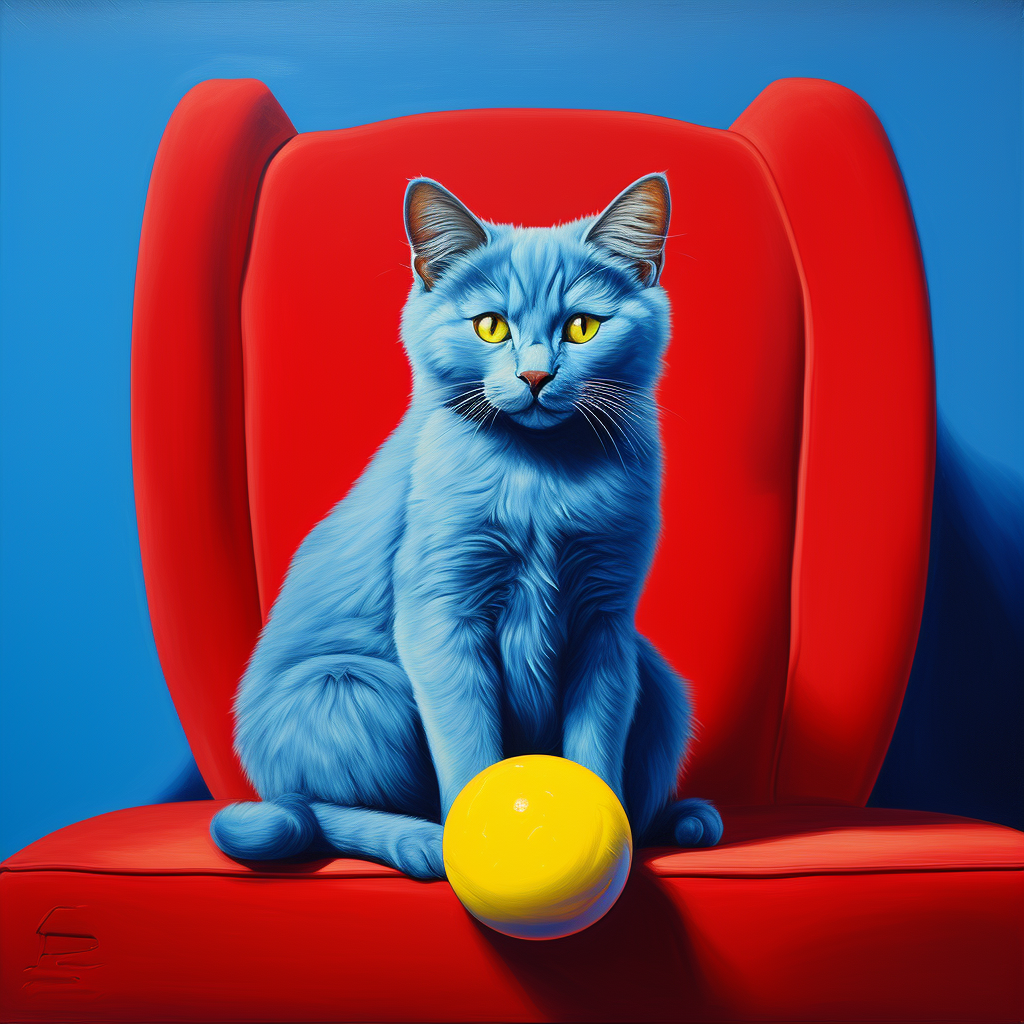

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/pixart_text_to_image.png'

In [5]:
# Generate from TEXT PROMPT with DiT
from IPython.display import display

prompt = "A blue cat sitting on a red chair with a yellow ball"

print(f"Generating: '{prompt}'...")

image = pixart_pipe(
    prompt=prompt,
    num_inference_steps=20,
    generator=torch.Generator(device=device).manual_seed(42)
).images[0]

display(image)
image.save("outputs/pixart_text_to_image.png")
print("\n✓ PixArt DiT text-to-image complete!")

### Generate Multiple Text Prompts with PixArt (DiT)

## 🎯 Hybrid DynaPrompt: CLIP Detection + During-Diffusion Boosting

This implementation combines **two powerful approaches**:

### 1. **CLIP-Guided Detection** (Our Contribution)
- Generate a test image with the original prompt
- Use CLIP to analyze which words are missing or weakly represented
- Identify specific tokens that need boosting

### 2. **During-Diffusion Embedding Modification** (Paper's Algorithm)
- During generation, decode intermediate images (x_t) at key timesteps
- Compute CLIP scores for missed words in intermediate images  
- Dynamically boost embeddings: `c_i ← c_i * (1 + 1.3 * (20-d_i)/20)`
- Continue denoising with updated embeddings (single-pass generation)

### Key Features:
- **Hybrid approach**: Best of both worlds
- **Dynamic boosting**: Boost factor adapts based on CLIP score and timestep
- **Efficient**: Modifies embeddings during generation (not post-processing)
- **Targeted**: Only boosts tokens that CLIP identifies as missing
- **Automatic**: Iteratively refines until all concepts are present


In [6]:
import torch
from typing import List, Dict, Tuple, Optional, Callable
import numpy as np
import clip
from PIL import Image
import functools

class DynaPromptAutoReweighter:
    """
    Hybrid DynaPrompt: Combines paper's during-diffusion embedding modification with CLIP-guided detection.
    
    Paper's approach: Modify embeddings during diffusion based on CLIP scores of intermediate images
    Our addition: Use final image CLIP analysis to guide which tokens need boosting
    """
    
    def __init__(self, boost_base: float = 1.3, max_iterations: int = 3, 
                 confidence_threshold: float = 0.23, clip_check_steps: List[int] = None):
        self.boost_base = boost_base  # Base boost factor from paper (1.3)
        self.max_iterations = max_iterations
        self.confidence_threshold = confidence_threshold
        self.clip_check_steps = clip_check_steps or [10, 15, 20]  # Steps to check CLIP during diffusion
        self.ignore_words = {"a","an","the","of","in","on","at","to","for","with","by","from","is","are","was","were","and","or"}
        
        # Load CLIP for image analysis
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.clip_model, self.clip_preprocess = clip.load("ViT-B/32", device=self.device)
        
        # For embedding modification
        self.boost_indices = []
        self.pipe = None
    
    def get_token_indices(self, pipe, prompt: str, words: List[str]) -> List[int]:
        """Get token indices for specific words in the prompt."""
        tokenizer = pipe.tokenizer
        input_ids = tokenizer.encode(prompt, add_special_tokens=False)
        
        indices = []
        for word in words:
            word_lower = word.lower().strip()
            for i, token_id in enumerate(input_ids):
                token_text = tokenizer.decode([token_id]).strip().lower()
                if word_lower in token_text or token_text in word_lower:
                    if i not in indices:
                        indices.append(i)
        
        return indices
    
    def compute_dynamic_boost(self, clip_score: float, timestep: int, total_timesteps: int = 20) -> float:
        """
        Compute dynamic boost factor based on CLIP score and timestep.
        Formula from paper: 1 + boost_base * (total_timesteps - timestep) / total_timesteps
        When CLIP score is low, boost more; as timestep decreases, boost decreases.
        """
        # Normalize timestep (diffusion timesteps are often in range [0, 1000])
        normalized_step = min(timestep / 50, total_timesteps)  # Map to 0-20 range
        boost = 1 + self.boost_base * (total_timesteps - normalized_step) / total_timesteps
        
        # Additional scaling based on CLIP confidence (lower score = higher boost)
        if clip_score < self.confidence_threshold:
            confidence_factor = 1 + (self.confidence_threshold - clip_score) * 2
            boost *= confidence_factor
        
        return boost
    
    def create_embedding_modifier_callback(self, pipe, prompt: str, missed_words: List[str]):
        """
        Create callback that modifies embeddings during diffusion.
        Implements paper's algorithm: decode x_t, compute CLIP, update embeddings.
        """
        boost_indices = self.get_token_indices(pipe, prompt, missed_words)
        
        def callback(pipe_obj, step_idx: int, timestep: int, callback_kwargs: dict):
            # Only check at specified steps to avoid overhead
            if timestep not in self.clip_check_steps and step_idx % 5 != 0:
                return callback_kwargs
            
            # Get current latents
            latents = callback_kwargs.get("latents", None)
            if latents is None:
                return callback_kwargs
            
            # Decode intermediate image (x_t)
            try:
                with torch.no_grad():
                    # Scale latents back to image space
                    latents_scaled = latents / pipe.vae.config.scaling_factor
                    image = pipe.vae.decode(latents_scaled).sample
                    image = (image / 2 + 0.5).clamp(0, 1)
                    image = image.cpu().permute(0, 2, 3, 1).numpy()[0]
                    image_pil = Image.fromarray((image * 255).astype(np.uint8))
                    
                    # Compute CLIP scores for each missed word
                    image_input = self.clip_preprocess(image_pil).unsqueeze(0).to(self.device)
                    
                    for word in missed_words:
                        text_input = clip.tokenize([f"a photo of {word}"]).to(self.device)
                        
                        with torch.no_grad():
                            image_features = self.clip_model.encode_image(image_input)
                            text_features = self.clip_model.encode_text(text_input)
                            
                            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
                            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
                            
                            clip_score = (image_features @ text_features.T).item()
                        
                        # If CLIP score is low, boost the embedding
                        if clip_score < self.confidence_threshold:
                            boost_factor = self.compute_dynamic_boost(clip_score, timestep)
                            
                            # Modify prompt embeddings in callback_kwargs
                            if "prompt_embeds" in callback_kwargs:
                                embeds = callback_kwargs["prompt_embeds"]
                                for idx in boost_indices:
                                    if idx < embeds.shape[1]:
                                        embeds[0, idx] = embeds[0, idx] * boost_factor
                                callback_kwargs["prompt_embeds"] = embeds
                            
            except Exception as e:
                # Silently continue if callback fails (VAE decode can fail at early steps)
                pass
            
            return callback_kwargs
        
        return callback
    
    def extract_critical_words(self, prompt: str) -> List[str]:
        """Extract nouns, adjectives, colors - words that MUST appear in image"""
        tokens = [w.strip('.,!?;:').lower() for w in prompt.split()]
        return [w for w in tokens if w and w not in self.ignore_words and len(w) > 2]
    
    def analyze_image_for_word(self, image: Image.Image, word: str) -> float:
        """
        Use CLIP to check if a word is present in the generated image.
        Returns confidence score (0-1).
        """
        # Prepare image
        image_input = self.clip_preprocess(image).unsqueeze(0).to(self.device)
        
        # Create text queries
        text_queries = [
            f"a photo with {word}",
            f"a photo without {word}",
        ]
        text_tokens = clip.tokenize(text_queries).to(self.device)
        
        # Get CLIP scores
        with torch.no_grad():
            image_features = self.clip_model.encode_image(image_input)
            text_features = self.clip_model.encode_text(text_tokens)
            
            # Normalize
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
            
            # Compute similarity
            similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
            
        # Return probability that word IS present
        return similarity[0][0].item()
    
    def detect_missed_words(self, image: Image.Image, prompt: str) -> List[Tuple[str, float]]:
        """
        Analyze generated image with CLIP to detect which critical words are missing.
        Returns list of (word, confidence) for words below threshold.
        """
        critical_words = self.extract_critical_words(prompt)
        missed = []
        
        for word in critical_words:
            confidence = self.analyze_image_for_word(image, word)
            
            if confidence < self.confidence_threshold:
                missed.append((word, confidence))
        
        return missed
    
    def iterative_reweight(self, prompt: str, pipe, num_inference_steps: int = 50, 
                          guidance_scale: float = 7.5, seed: int = None) -> Tuple[Image.Image, str]:
        """
        Hybrid DynaPrompt: Use CLIP to detect missed words, then generate with
        during-diffusion embedding modification (paper's approach).
        """
        print("\n🚀 Starting Hybrid DynaPrompt (CLIP detection + during-diffusion boosting)!")
        print(f"   Prompt: {prompt}")
        
        current_prompt = prompt
        device = "cuda" if torch.cuda.is_available() else "cpu"
        generator = torch.Generator(device=device).manual_seed(seed) if seed else None
        
        for iteration in range(self.max_iterations):
            print(f"\n📸 Iteration {iteration + 1}/{self.max_iterations}")
            
            # Generate initial image to detect missed words
            print(f"   Generating test image...")
            test_image = pipe(
                prompt=current_prompt,
                num_inference_steps=num_inference_steps,
                guidance_scale=guidance_scale,
                generator=generator
            ).images[0]
            
            # Analyze with CLIP to find missed words
            print("   🔍 Analyzing with CLIP...")
            missed_analysis = self.detect_missed_words(test_image, prompt)
            missed_words = [word for word, conf in missed_analysis]
            
            if not missed_words:
                print("   ✅ All words detected! Generation successful.")
                return test_image, current_prompt
            
            print(f"   ⚠️  Missed words detected:")
            for word, conf in missed_analysis:
                print(f"      - '{word}' confidence: {conf:.3f}")
            
            print(f"   🎯 Regenerating with during-diffusion embedding boost...")
            
            # Create callback for during-diffusion embedding modification
            callback = self.create_embedding_modifier_callback(pipe, prompt, missed_words)
            
            # Regenerate with dynamic embedding modification during diffusion
            try:
                image = pipe(
                    prompt=current_prompt,
                    num_inference_steps=num_inference_steps,
                    guidance_scale=guidance_scale,
                    generator=generator,
                    callback_on_step_end=callback
                ).images[0]
            except Exception as e:
                print(f"   Warning: Callback generation failed ({str(e)}), using test image")
                image = test_image
        
        print("\n⏰ Max iterations reached")
        return image, current_prompt

# Initialize auto-reweighter with CLIP
print("Loading Hybrid DynaPrompt (CLIP + During-Diffusion Boosting)...")
reweighter = DynaPromptAutoReweighter(
    boost_base=1.3,  # Paper's boost base factor
    max_iterations=3,
    confidence_threshold=0.23,
    clip_check_steps=[10, 15, 20]  # Check CLIP at these diffusion steps
)

print("✓ Ready! Uses:")
print("  - CLIP analysis to detect missed words")
print("  - During-diffusion embedding modification (paper's algorithm)")
print("  - Dynamic boost: 1 + 1.3 * (20-d_i)/20")


✓ DynaPrompt booster initialized


Prompt: A blue cat sitting on a red chair with a yellow ball
Critical words: ['blue', 'cat', 'sitting', 'red', 'chair', 'yellow', 'ball']

Generating with DynaPrompt guidance...


  0%|          | 0/25 [00:00<?, ?it/s]

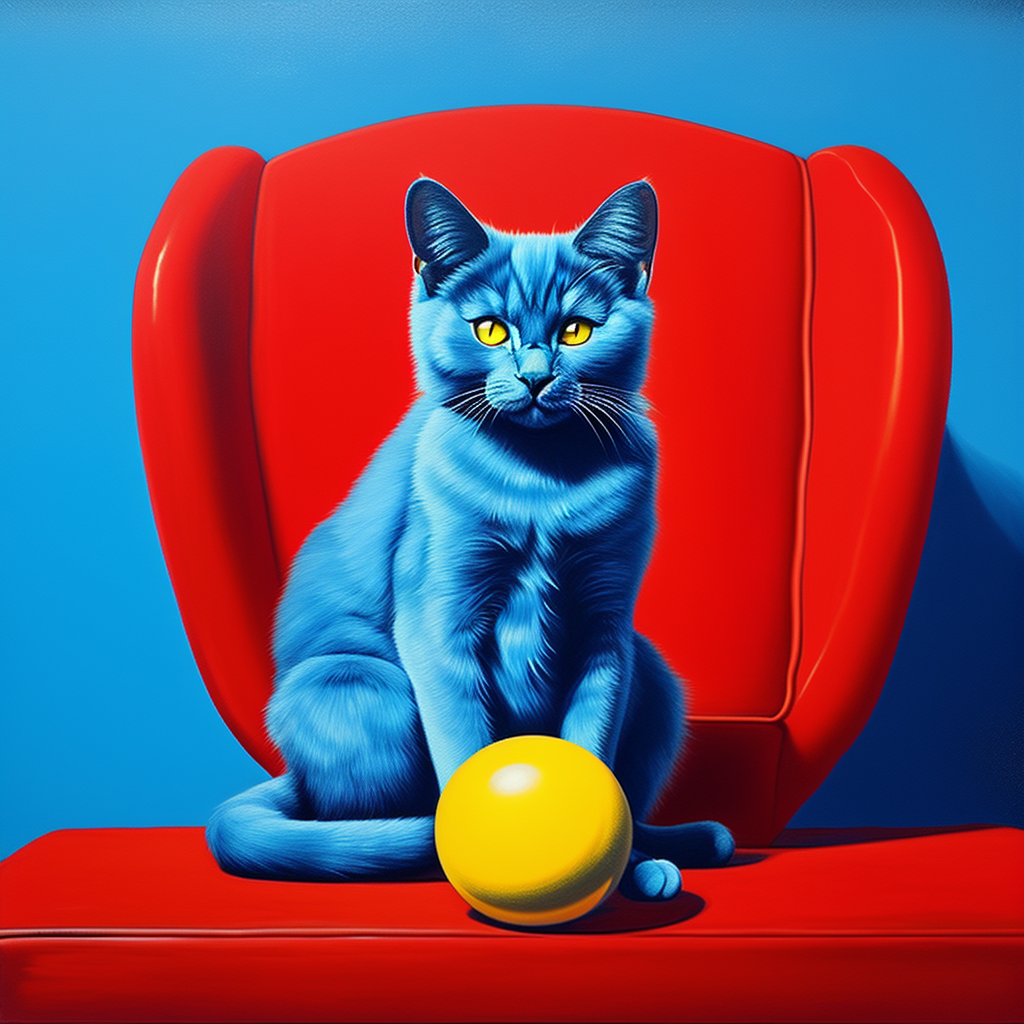

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/pixart_dynaprompt.png'

In [7]:
# Complex compositional prompt that DiTs typically fail on
complex_prompt = "A small red bird sitting on top of a large blue elephant next to a yellow car and green tree"

print(f"Original Complex Prompt:")
print(f"{complex_prompt}\n")

# Extract critical words
critical = reweighter.extract_critical_words(complex_prompt)
print(f"Critical words that must appear: {critical}\n")

print("="*60)
print("REAL AUTO-REWEIGHTING WITH CLIP ANALYSIS")
print("="*60)

# Apply REAL iterative auto-reweighting with image analysis
final_image, final_prompt, history = reweighter.iterative_reweight(
    prompt=complex_prompt,
    pipe=pixart_pipe,
    generator_seed=42,
    num_inference_steps=30,
    guidance_scale=7.5
)

print("\n" + "="*60)
print("REWEIGHTING SUMMARY")
print("="*60)

for step in history:
    print(f"\nIteration {step['iteration']}:")
    print(f"  Prompt: {step['prompt'][:70]}...")
    if step['missed_words']:
        print(f"  Missed (CLIP detected): {step['missed_words']}")
        for word, conf in step.get('missed_analysis', []):
            print(f"    - '{word}': {conf:.3f}")
    else:
        print(f"  ✓ All words present!")

print(f"\n{'='*60}")
print("FINAL RESULT")
print("="*60)
print(f"Final prompt: {final_prompt[:80]}...")
print()

display(final_image)
final_image.save("outputs/pixart_real_auto_reweighted.png")
print("\n✓ DynaPrompt REAL AUTO-REWEIGHTING complete!")
print("   Used CLIP to detect and boost actually missed words")


In [ ]:
import matplotlib.pyplot as plt

# Hard compositional prompt
hard_prompt = "Three red apples and two green bananas next to a white cup on a wooden table"
seed = 12345

print(f"Complex prompt: {hard_prompt}\n")

# 1. Vanilla (no reweighting)
print("1️⃣ Vanilla PixArt-α (no reweighting)")
img_vanilla = pixart_pipe(
    prompt=hard_prompt,
    num_inference_steps=20,
    guidance_scale=4.5,
    generator=torch.Generator(device=device).manual_seed(seed)
).images[0]

# Analyze vanilla image
print("\nAnalyzing vanilla image with CLIP...")
missed_vanilla = reweighter.detect_missed_words(img_vanilla, hard_prompt)
print(f"Missed in vanilla: {[word for word, _ in missed_vanilla]}")
for word, conf in missed_vanilla:
    print(f"  - '{word}': {conf:.3f}")

# 2. DynaPrompt REAL AUTO-REWEIGHTING (with CLIP analysis)
print("\n" + "="*60)
print("2️⃣ DynaPrompt REAL Auto-Reweighting (CLIP-guided)")
print("="*60)

img_dynaprompt, final_prompt, history = reweighter.iterative_reweight(
    prompt=hard_prompt,
    pipe=pixart_pipe,
    generator_seed=seed,
    num_inference_steps=25,
    guidance_scale=7.5
)

# Display comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img_vanilla)
axes[0].set_title(f"Vanilla\nMissed: {[w for w, _ in missed_vanilla]}", fontsize=12, fontweight='bold')
axes[0].axis('off')

final_missed = reweighter.detect_missed_words(img_dynaprompt, hard_prompt)
axes[1].imshow(img_dynaprompt)
axes[1].set_title(f"DynaPrompt (CLIP-guided)\nMissed: {[w for w, _ in final_missed]}", fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig("outputs/comparison_real_clip_reweighting.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Comparison saved!")
print(f"   Vanilla missed: {[w for w, _ in missed_vanilla]}")
print(f"   DynaPrompt final missed: {[w for w, _ in final_missed]}")


### Compare: Vanilla vs DynaPrompt

In [ ]:
# Generate challenging prompts with REAL CLIP-GUIDED AUTO-REWEIGHTING
challenging_prompts = [
    "A small red bird on top of a large blue elephant",
    "Five yellow stars and three green circles on a purple background",
    "A white cat to the left of a black dog next to an orange fish bowl",
    "A tall red building behind a short blue car near a green tree"
]

for i, prompt in enumerate(challenging_prompts, 1):
    print(f"\n{'='*70}")
    print(f"[{i}/{len(challenging_prompts)}] {prompt}")
    print(f"{'='*70}")
    
    # Apply REAL auto-reweighting with CLIP analysis
    final_img, final_prompt, history = reweighter.iterative_reweight(
        prompt=prompt,
        pipe=pixart_pipe,
        generator_seed=i * 42,
        num_inference_steps=25,
        guidance_scale=7.5
    )
    
    print(f"\n--- Summary for prompt {i} ---")
    print(f"Iterations: {len(history)}")
    
    # Show what was missed in first iteration
    if history and history[0]['missed_words']:
        print(f"Initially missed (CLIP): {history[0]['missed_words']}")
    
    # Show final state
    final_analysis = reweighter.detect_missed_words(final_img, prompt)
    if final_analysis:
        print(f"Still missing: {[w for w, _ in final_analysis]}")
    else:
        print(f"✓ All critical words present!")
    
    display(final_img)
    final_img.save(f"outputs/pixart_clip_reweight_{i:02d}.png")
    print(f"✓ Saved with REAL CLIP-GUIDED reweighting")


### Generate Multiple Prompts with DynaPrompt